In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import train_score_network, generate_initial_data, rollout, time_reversal, noise, time_reversal_bsde, train_phi_network
from network import ScoreNetwork, PhiNetwork

In [2]:
N = 1000  # number of samples
n = 1    # dimension of state
m = 1    # dimension of noise
T = 1.0   # terminal time
steps = 50  # number of time steps
dt = T / steps  # time step size


In [3]:
INITIAL_DIST = 'Bimodal'  # 'Gaussian' or 'Bimodal'
shift = 3.0
m_0 = torch.tensor([0.0])  # Mean of initial distribution
sigma_0 = torch.eye(n) * 1  # Covariance of initial distribution

In [4]:
X_0 = generate_initial_data(INITIAL_DIST, m_0, sigma_0, N, shift)
time_grid = torch.arange(0, steps+1) * dt

In [5]:
a = -2.0
sigma = 2

In [6]:
X = torch.zeros((steps+1, N, n))
X[0] = X_0

In [7]:
for i in range(steps):
    X[i+1] = X[i] + a * X[i] * dt + sigma * noise(dt, N, m)

Text(0.5, 0, 'Time Steps')

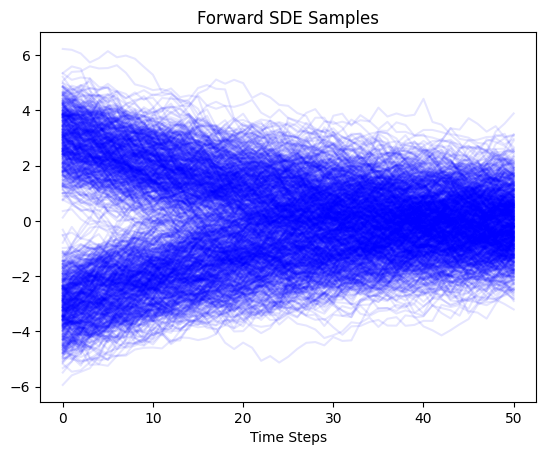

In [8]:
plt.figure()
plt.plot(X[:, :, 0].numpy(), alpha=0.1, color='blue')
plt.title('Forward SDE Samples')
plt.xlabel('Time Steps')

In [9]:
X[-1].mean(dim=0), X[-1].std(dim=0)

(tensor([-0.0759]), tensor([1.0999]))

In [10]:
score_nn = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=32, num_blocks=2)
score_optimizer = torch.optim.AdamW(score_nn.parameters(), lr=1e-3, weight_decay=1e-4)
score_scheduler = torch.optim.lr_scheduler.StepLR(score_optimizer, step_size=500, gamma=0.9)

In [11]:
def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.tensor([[1.0]]) * sigma
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

In [12]:
score_loss_history = train_score_network(score_nn, X, time_grid, g, 1, score_optimizer, score_scheduler, batch_size=32, iterations=3000)

Iteration 0, Loss: 0.014600260183215141
Iteration 500, Loss: -0.3681812584400177
Iteration 1000, Loss: -0.3740253448486328
Iteration 1500, Loss: -0.3151282072067261
Iteration 2000, Loss: -0.27965450286865234
Iteration 2500, Loss: -0.43493303656578064
Iteration 2999, Loss: -0.34807902574539185


In [13]:
time_grid.shape

torch.Size([51])

In [14]:
# time reversal
X_rev = torch.zeros((steps+1, N, n))
X_rev[-1] = torch.randn((N,n))

In [15]:
for i in range(steps-1, -1, -1):
    t = time_grid[i+1].repeat(N, 1)  # (N, 1)
    score = score_nn(X_rev[i+1,:,:], t).detach()  # (N, n)
    X_rev[i] = X_rev[i+1] - a * X_rev[i+1] * dt + sigma * noise(dt, N, m) + sigma**2 * score * dt

Text(0.5, 0, 'Time Steps')

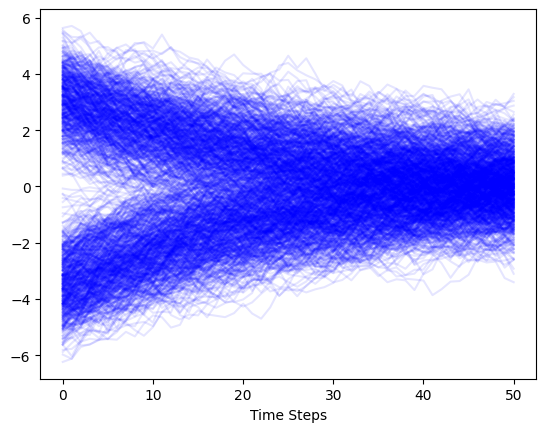

In [16]:
plt.figure()
plt.plot(X_rev[:, :, 0].numpy(), alpha=0.1, color='blue')
# plt.plot(X[:, :, 0].numpy(), alpha=0.1, color='red')
# plt.title('Backward SDE Samples')
plt.xlabel('Time Steps')

In [17]:
torch.save(score_nn.state_dict(), f'network/toy_score_network_timesteps{steps}.pth')